# Антиферромагнитная спиновая цепочка XXX: точная диагонализация

Для спинов $1/2$ при $J=1$ решаем

$$H=\sum_{(i,j)}\mathbf S_i\cdot\mathbf S_j
=\sum_{(i,j)}\left[S_i^zS_j^z+\tfrac12(S_i^+S_j^-+S_i^-S_j^+)\right].$$

При открытых граничных условиях (ОГУ) связи $(i,i+1)$ имеют $i=0,\ldots,N-2$.
При периодических (ПГУ) добавляется связь $(N-1,0)$. Рассчитываем чётные
$N=4,6,\ldots,16$ и сравниваем $e_0(N)=E_0(N)/N$ с
$e_\infty=\tfrac14-\ln 2\simeq -0.44314718$.


## Базис и разреженный гамильтониан

Состояние $|s\rangle$ кодируется целым числом: бит $i=1$ означает
$S_i^z=+1/2$. Полная намагниченность сохраняется, поэтому для чётного
антиферромагнитного кольца и открытой цепочки рассматриваем сектор
$S^z_{\rm total}=0$ с $\binom{N}{N/2}$ состояниями.

Для пары спинов вклад в $H_{ss}$ равен $+1/4$ при равных битах и $-1/4$
при разных. Если биты различаются, состояние
$s'=s\mathbin{\mathrm{xor}}2^i\mathbin{\mathrm{xor}}2^j$ получает
$H_{s's}=1/2$. Функции построения матрицы находятся в `xxx_chain.py`:
Numba обрабатывает блоки состояний, SciPy собирает CSR-матрицу и находит
минимальное собственное значение алгоритмом Ланцоша (`eigsh`, `which="SA"`).
Две разные начальные точки и невязка $\lVert H\psi-E_0\psi\rVert_2$
контролируют численную сходимость.


In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from xxx_chain import compute_grid

E_INFINITY = 0.25 - np.log(2.0)
SIZES = (4, 6, 8, 10, 12, 14, 16)
# Значение выбрано по benchmark.py; менять в диапазоне 1..14.
WORKERS = 1
print(f"Аналитический предел: {E_INFINITY:.12f}; процессов: {WORKERS}")


Аналитический предел: -0.443147180560; процессов: 1


In [2]:
results = compute_grid(SIZES, workers=WORKERS, progress=True)
fields = ("N", "boundary", "dimension", "E0", "e0", "residual", "norm_error", "repeat_delta")
with open("results.csv", "w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=fields)
    writer.writeheader()
    writer.writerows(results)
print("Сохранено: results.csv")


Цепочки:   0%|          | 0/14 [00:00<?, ?it/s]

H N=14 OBC:   0%|          | 0/4 [00:00<?, ?it/s]

H N=14 PBC:   0%|          | 0/4 [00:00<?, ?it/s]

H N=16 OBC:   0%|          | 0/13 [00:00<?, ?it/s]

H N=16 PBC:   0%|          | 0/13 [00:00<?, ?it/s]

Сохранено: results.csv


In [3]:
lines = ["| N | Границы | Размерность | E₀ | E₀/N | Невязка | Δ повтора |",
         "|---:|:---:|---:|---:|---:|---:|---:|"]
for row in results:
    lines.append(f"| {row['N']} | {row['boundary']} | {row['dimension']} | "
                 f"{row['E0']:.10f} | {row['e0']:.10f} | "
                 f"{row['residual']:.2e} | {row['repeat_delta']:.2e} |")
display(Markdown("\n".join(lines)))


| N | Границы | Размерность | E₀ | E₀/N | Невязка | Δ повтора |
|---:|:---:|---:|---:|---:|---:|---:|
| 4 | OBC | 6 | -1.6160254038 | -0.4040063509 | 5.10e-16 | 4.44e-16 |
| 4 | PBC | 6 | -2.0000000000 | -0.5000000000 | 4.97e-16 | 4.44e-16 |
| 6 | OBC | 20 | -2.4935771339 | -0.4155961890 | 1.78e-15 | 8.88e-16 |
| 6 | PBC | 20 | -2.8027756377 | -0.4671292730 | 1.69e-15 | 1.78e-15 |
| 8 | OBC | 70 | -3.3749325987 | -0.4218665748 | 9.35e-12 | 2.66e-15 |
| 8 | PBC | 70 | -3.6510934089 | -0.4563866761 | 8.89e-14 | 0.00e+00 |
| 10 | OBC | 252 | -4.2580352073 | -0.4258035207 | 3.18e-12 | 1.78e-15 |
| 10 | PBC | 252 | -4.5154463545 | -0.4515446354 | 7.26e-14 | 8.88e-16 |
| 12 | OBC | 924 | -5.1420906328 | -0.4285075527 | 6.41e-13 | 0.00e+00 |
| 12 | PBC | 924 | -5.3873909174 | -0.4489492431 | 4.49e-14 | 4.44e-15 |
| 14 | OBC | 3432 | -6.0267246619 | -0.4304803330 | 1.72e-12 | 1.07e-14 |
| 14 | PBC | 3432 | -6.2635495335 | -0.4473963953 | 5.50e-11 | 1.78e-15 |
| 16 | OBC | 12870 | -6.9117371456 | -0.4319835716 | 3.05e-12 | 7.11e-15 |
| 16 | PBC | 12870 | -7.1422963606 | -0.4463935225 | 1.15e-11 | 1.07e-14 |

## Конечномерное приближение

Для оценки перехвата используем четыре наибольших размера: линейную модель
$e_0^{\rm ОГУ}(N)=a+b/N$ и, из-за отсутствия краевых вкладов, модель
$e_0^{\rm ПГУ}(N)=a+c/N^2$. Это простые конечномерные оценки, а не
доказательство асимптотического закона; главный эталон здесь — аналитическое
$e_\infty$.


In [4]:
fits = {}
for boundary in ("OBC", "PBC"):
    subset = [row for row in results if row["boundary"] == boundary and row["N"] >= 10]
    n = np.array([row["N"] for row in subset], dtype=float)
    e = np.array([row["e0"] for row in subset], dtype=float)
    x = 1 / n if boundary == "OBC" else 1 / n**2
    slope, intercept = np.polyfit(x, e, 1)
    fits[boundary] = (slope, intercept)
    print(f"{boundary}: e∞≈{intercept:.10f}; отличие от 1/4−ln2 = {intercept-E_INFINITY:+.3e}")


OBC: e∞≈-0.4422570607; отличие от 1/4−ln2 = +8.901e-04
PBC: e∞≈-0.4430847874; отличие от 1/4−ln2 = +6.239e-05


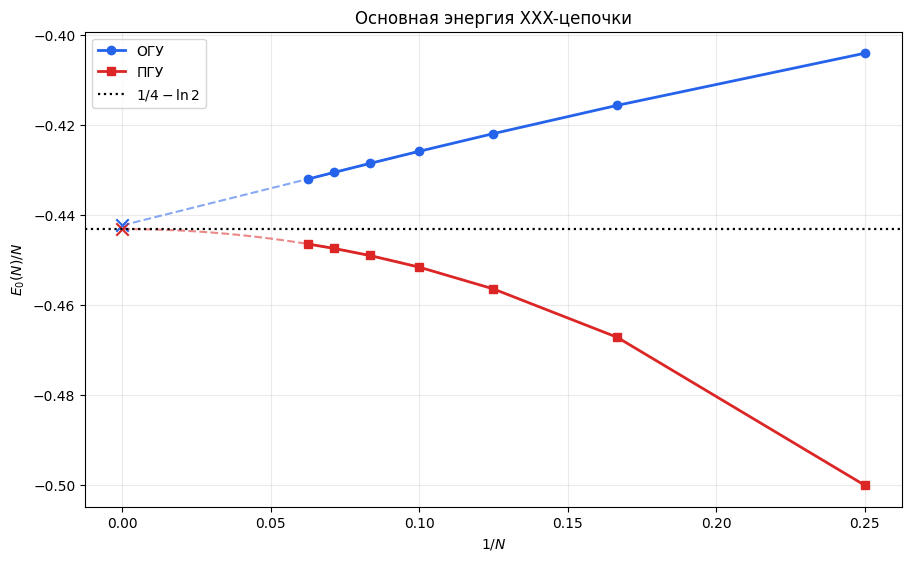

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
styles = {"OBC": ("#2563eb", "o", "ОГУ"),
          "PBC": ("#dc2626", "s", "ПГУ")}
for boundary in ("OBC", "PBC"):
    subset = [row for row in results if row["boundary"] == boundary]
    x = np.array([1 / row["N"] for row in subset])
    y = np.array([row["e0"] for row in subset])
    color, marker, label = styles[boundary]
    ax.plot(x, y, marker=marker, color=color, linewidth=2, label=label)
    slope, intercept = fits[boundary]
    fit_x = np.linspace(0, 0.1, 100)
    fit_y = intercept + slope * (fit_x if boundary == "OBC" else fit_x**2)
    ax.plot(fit_x, fit_y, color=color, linestyle="--", alpha=0.55)
    ax.scatter([0], [intercept], marker="x", s=80, color=color)
ax.axhline(E_INFINITY, color="black", linestyle=":", linewidth=1.6,
           label=r"$1/4-\ln 2$")
ax.set_xlabel(r"$1/N$")
ax.set_ylabel(r"$E_0(N)/N$")
ax.set_title("Основная энергия XXX-цепочки")
ax.grid(alpha=0.25)
ax.legend()
fig.savefig("energies.png", dpi=180)
plt.show()


## Почему результату можно доверять

`validate.py` независимо собирает малые гамильтонианы из произведений
матриц Паули $S^\alpha=\sigma^\alpha/2$ и сравнивает их элементы и спектры
с битовым построением для $N=4,6,8$. Он также проверяет все секторы
намагниченности, точное $E_0(4,\mathrm{ПГУ})=-2$, эрмитовость,
энергию поляризованного состояния, невязки и согласие двух запусков
`eigsh` для каждого $N\leq16$. Запуск до выполнения notebook:

```bash
docker compose run --rm notebook python validate.py
```

Для чётной антиферромагнитной цепочки на двудольной решётке основное
состояние имеет полный спин $S=0$ и потому входит в сектор $S^z=0$.
Сходимость конечных значений к $1/4-\ln2$ служит дополнительной,
но не единственной проверкой.


## Ресурсы Docker и практический предел $N$

Замеры сделаны командой `docker compose run --rm -T notebook python
profile_resources.py N PBC` для каждого размера в **отдельном контейнере**.
Перед замером разогреваются JIT-функции Numba; далее учитываются построение
матрицы и один запуск `eigsh`. Время — настенное (`perf_counter`), CPU —
процессорное (`process_time`), пик памяти — `ru_maxrss` процесса. Процент CPU
равен $100\,t_{CPU}/t_{wall}$: 100% соответствует одному полностью занятому
логическому ядру, а не всему процессору. Данные относятся к ПГУ как к
более плотной из двух рассматриваемых матриц. Файл `resource_measurements.csv`
содержит исходные числа и может быть обновлён повторными запусками профайлера.

На проверенной конфигурации Docker сообщает **16 логических CPU** и
**15,34 ГиБ памяти**. Хотя в ноутбуке установлено 32 ГБ ОЗУ, текущий
Docker Desktop предоставляет контейнерам около половины этого объёма.
Лимит cgroup самого сервиса не задан; ориентиром служит память Docker VM.


In [6]:
from math import comb

with open("resource_measurements.csv", newline="", encoding="utf-8") as handle:
    usage = list(csv.DictReader(handle))
memory_limit_gib = 15.340023040771484
lines = ["| N | Размерность Sᶻ=0 | Ненулевых элементов | Время, с | CPU, с | CPU, % ядра | Пик RAM, ГиБ | CSR, ГиБ |",
         "|---:|---:|---:|---:|---:|---:|---:|---:|"]
for row in usage:
    lines.append(f"| {row['N']} | {int(row['dimension']):,} | {int(row['nnz']):,} | "
                 f"{float(row['wall_seconds']):.2f} | {float(row['cpu_seconds']):.2f} | "
                 f"{float(row['cpu_percent_one_core']):.1f} | "
                 f"{float(row['peak_rss_gib']):.2f} | {float(row['csr_gib']):.3f} |")
display(Markdown("\n".join(lines)))

last = usage[-1]
def candidate_entries(n):
    return comb(n, n // 2) + n * 2 * comb(n - 2, n // 2 - 1)

estimated_28 = float(last["peak_rss_gib"]) * candidate_entries(28) / candidate_entries(26)
print(f"Docker: 16 CPU, {memory_limit_gib:.2f} ГиБ RAM. "
      f"N=26 проверен: {float(last['peak_rss_gib']):.2f} ГиБ; "
      f"N=28 оценка: ~{estimated_28:.1f} ГиБ.")


| N | Размерность Sᶻ=0 | Ненулевых элементов | Время, с | CPU, с | CPU, % ядра | Пик RAM, ГиБ | CSR, ГиБ |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 16 | 12,870 | 117,794 | 0.03 | 0.03 | 90.9 | 0.15 | 0.001 |
| 18 | 48,620 | 511,940 | 0.22 | 0.19 | 86.8 | 0.17 | 0.006 |
| 20 | 184,756 | 2,066,052 | 1.42 | 1.29 | 90.9 | 0.25 | 0.024 |
| 22 | 705,432 | 8,834,696 | 7.13 | 6.47 | 90.8 | 0.54 | 0.101 |
| 24 | 2,704,156 | 35,711,116 | 24.85 | 22.59 | 90.9 | 1.78 | 0.409 |
| 26 | 10,400,600 | 151,016,712 | 118.91 | 108.07 | 90.9 | 6.80 | 1.726 |

Docker: 16 CPU, 15.34 ГиБ RAM. N=26 проверен: 6.80 ГиБ; N=28 оценка: ~28.0 ГиБ.


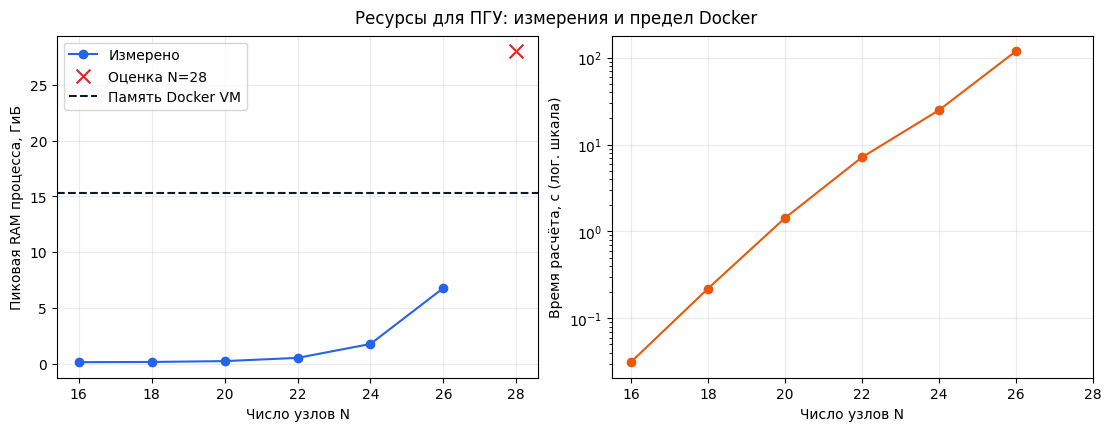

In [7]:
n_measured = np.array([int(row["N"]) for row in usage])
rss_measured = np.array([float(row["peak_rss_gib"]) for row in usage])
time_measured = np.array([float(row["wall_seconds"]) for row in usage])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
axes[0].plot(n_measured, rss_measured, "o-", color="#2563eb", label="Измерено")
axes[0].scatter([28], [estimated_28], marker="x", s=100,
                color="#dc2626", label="Оценка N=28")
axes[0].axhline(memory_limit_gib, color="#111827", linestyle="--",
                label="Память Docker VM")
axes[0].set_ylabel("Пиковая RAM процесса, ГиБ")
axes[0].legend()
axes[1].semilogy(n_measured, time_measured, "o-", color="#ea580c")
axes[1].set_ylabel("Время расчёта, с (лог. шкала)")
for ax in axes:
    ax.set_xlabel("Число узлов N")
    ax.set_xticks((16, 18, 20, 22, 24, 26, 28))
    ax.grid(alpha=0.25)
fig.suptitle("Ресурсы для ПГУ: измерения и предел Docker")
fig.savefig("resource_usage.png", dpi=180)
plt.show()


### Вывод о предельном размере

**$N=26$ проверен практически:** сектор содержит $\binom{26}{13}=10\,400\,600$
состояний, расчёт ПГУ занимает около 119 с и достигает пика 6,80 ГиБ.
Для $N=28$ сектор уже имеет $40\,116\,600$ состояний. Оценка около
**28 ГиБ** получена масштабированием измеренного пика $N=26$ по числу
кандидатных элементов разреженной матрицы. Это оценка, **не замер**;
она существенно превышает доступные Docker 15,34 ГиБ. Поэтому для
текущей реализации и настроек Docker практический максимум — **$N=26$**.

Готовая CSR-матрица занимает лишь часть пика: при построении одновременно
существуют блоки COO, их объединённые копии и индекс состояний. Чтобы идти
дальше, потребуется изменить хранение/построение гамильтониана (например,
вычислять действие $H$ на вектор без явной матрицы), а также заново измерить
время и память. Простое увеличение числа процессов для одного собственного
значения здесь не помогает: текущий `eigsh` загружает примерно одно ядро.
